# 과제 1: SVD로 이미지 압축 해보기
## 자신의 이미지를 SVD로 압축하고 k값에 따른 변화 관찰

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# 자신의 이미지 파일 경로 사용
img = np.array(Image.open('0163.jpg').convert('L')) 
# jpg가 numpy.array로 바뀌고 이걸 img에 저장함

In [3]:
img.shape

(1879, 3072)

In [4]:
# SVD 분해
U, s, VT = np.linalg.svd(img, full_matrices=False)
print(f"특잇값 개수: {len(s)}")

특잇값 개수: 1879


In [7]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'AppleGothic'  
plt.rcParams['axes.unicode_minus'] = False   

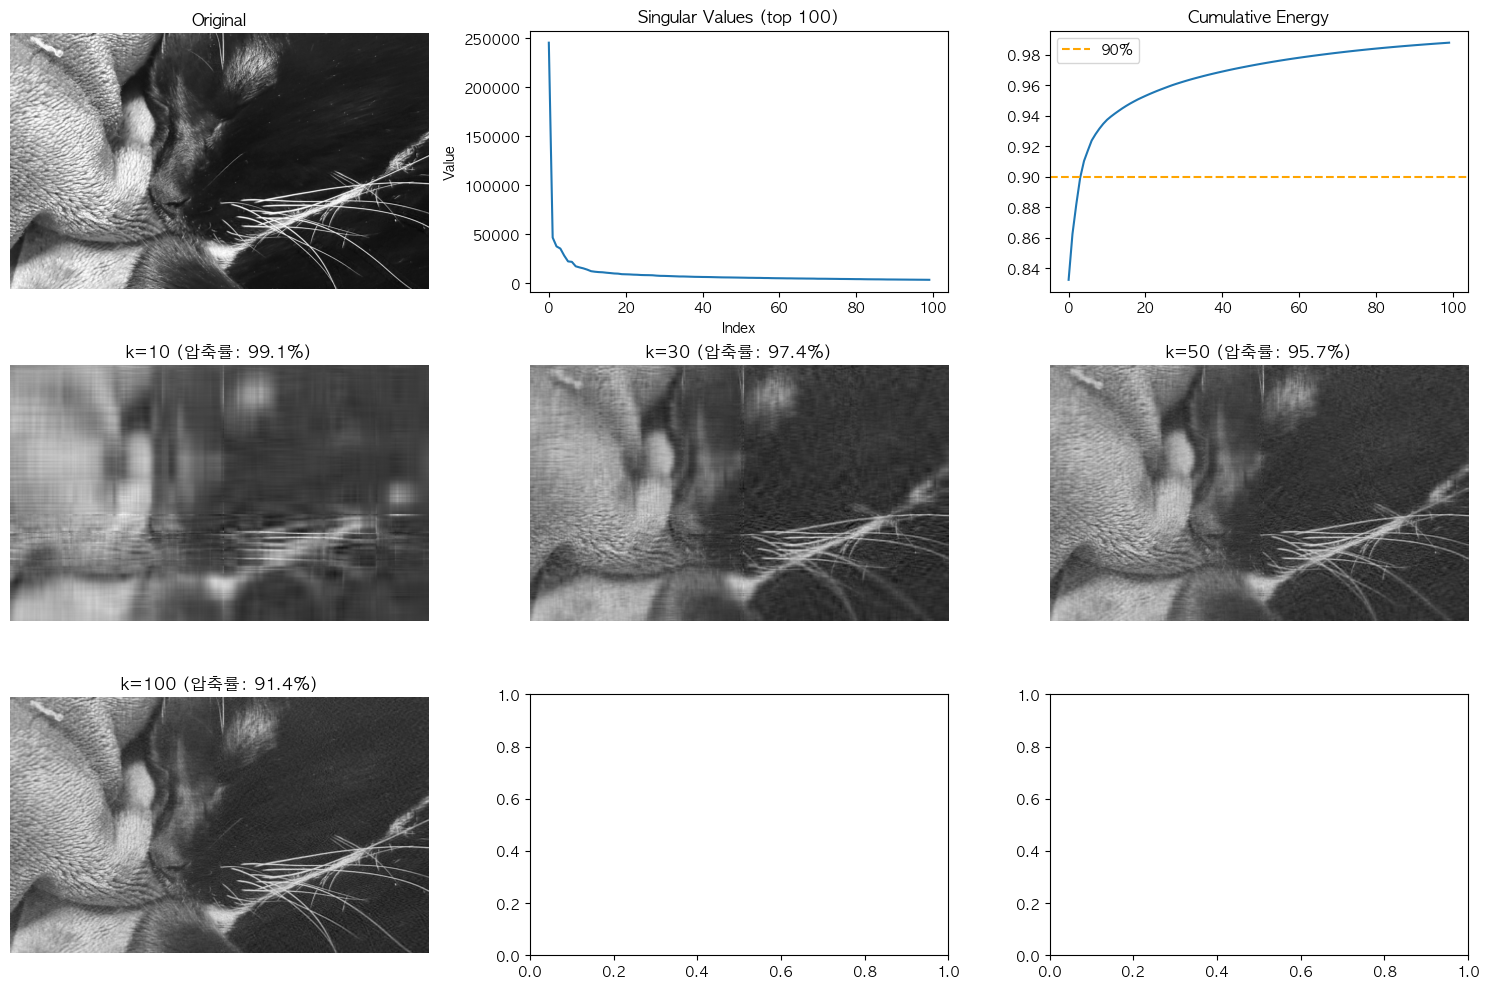

In [76]:
# 다양한 k 값으로 압축
k_values = [10, 30, 50,100]

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes[0, 0].imshow(img, cmap='gray')
axes[0, 0].set_title('Original')
axes[0, 0].axis('off')
# 특잇값 그래프
axes[0, 1].plot(s[:100])
axes[0, 1].set_title('Singular Values (top 100)')
axes[0, 1].set_xlabel('Index')
axes[0, 1].set_ylabel('Value')

# 누적 에너지
cumsum = np.cumsum(s**2) / np.sum(s**2)
axes[0, 2].plot(cumsum[:100])
axes[0, 2].set_title('Cumulative Energy')
axes[0, 2].axhline(y=0.9, color='orange', linestyle='--', label='90%')
axes[0, 2].legend()

for idx, k in enumerate(k_values):
    # k개 특잇값으로 재구성
    img_compressed = U[:, :k] @ np.diag(s[:k]) @ VT[:k, :]
    
    # 압축률 계산
    original_size = img.shape[0] * img.shape[1]
    compressed_size = k * (img.shape[0] + img.shape[1] + 1)
    ratio = (1 - compressed_size / original_size) * 100
    
    # 시각화
    row = 1 + idx // 3
    col = idx % 3
    axes[row, col].imshow(img_compressed, cmap='gray')
    axes[row, col].set_title(f'k={k} (압축률: {ratio:.1f}%)')
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

In [29]:
# 정보 보존률 계산
for k in k_values:
    energy = np.sum(s[:k]**2) / np.sum(s**2) * 100
    print(f"k={k}: 정보 보존률 {energy:.1f}%")

k=10: 정보 보존률 93.5%
k=30: 정보 보존률 96.2%
k=50: 정보 보존률 97.4%


# 과제 2: 파라미터 실험 
## eps와 min_samples 조정하기 → 최적 선택 및 결과 비교

In [10]:
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons, make_circles
from sklearn.neighbors import NearestNeighbors

In [39]:
# 복잡한 모양 데이터 생성
X1, _ = make_moons(n_samples=200, noise=0.05, random_state=0) # 달모양 데이터
X2, _ = make_circles(n_samples=200, noise=0.05, factor=0.5, random_state=0) # 원 모양 데이터
# make_moons(...) → 초승달 2개가 마주 보는 모양의 2D 데이터셋
# make_circles(...) → 동심원(바깥 원, 안쪽 원) 모양의 2D 데이터
# n_samples=200 → 각각 200개 점
# noise=0.05 → 약간의 노이즈
# random_state=0 → 매번 같은 데이터 나오게 씨드 고정

X2[:, 0] += 3  # X2의 x좌표 (첫 번째 열)에 +3 해서 x 축 방향으로 오른쪽에서 3만큼 민것 : X1이랑 X2를 한 화면에서 같이 보니까 옆으로 밀어줌
X = np.vstack([X1, X2])

# K-distance 그래프로 eps 찾기
k = 4  # min_samples 후보
neighbors = NearestNeighbors(n_neighbors=k) # 각 점마다 가장 가까운 k개 점을 계산함
neighbors.fit(X) # 학습시킴
distances, indices = neighbors.kneighbors(X)
# distances : 가까운 점 4개의 거리 , indices : 그 점의 거리

# eps : 몇 거리까지 이웃으로 볼 건지
# min_samples : 그 주변에 몇 명 이상 있으면 “밀도 높다”라고 볼지

In [40]:
distances.shape  # distances에는 400개 점 각각에 대해 가장 가까운 4개의 점의 거리가 들어있음

(400, 4)

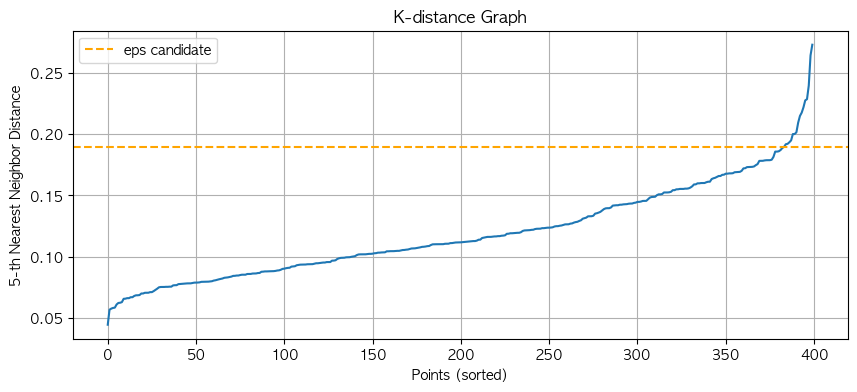

In [56]:
# k번째 거리만 (자기 자신 제외)
k_distances = np.sort(distances[:, k-1])
# distances[:, k-1] 는 “각 점에서 k번째로 가까운 이웃까지의 거리 
# np.sort(...) 해서 작은 것부터 큰 것 순서대로 나열
plt.figure(figsize=(10, 4))
plt.plot(k_distances)
plt.ylabel(f'{k}-th Nearest Neighbor Distance')
plt.xlabel('Points (sorted)')
plt.title('K-distance Graph')
plt.axhline(y=0.19, color='orange', linestyle='--', label='eps candidate')
plt.grid(True)
plt.legend()
plt.show()

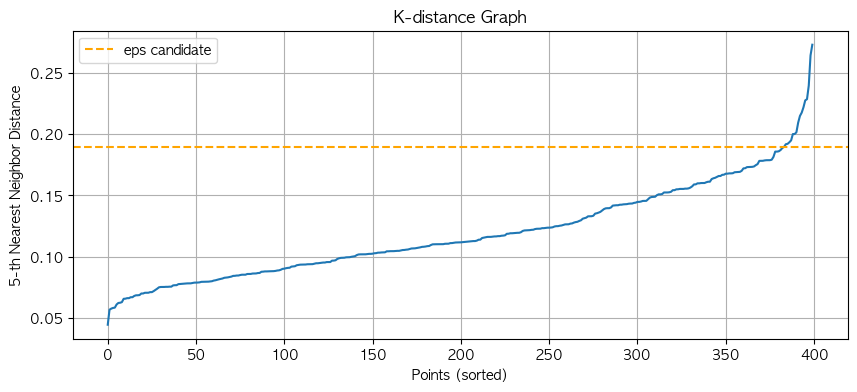

In [74]:
X1, _ = make_moons(n_samples=200, noise=0.06, random_state=0) 
X2, _ = make_circles(n_samples=200, noise=0.06, factor=0.5, random_state=0) 

X2[:, 0] += 3   
X = np.vstack([X1, X2])

k = 5
neighbors = NearestNeighbors(n_neighbors=k) 
neighbors.fit(X) 
distances, indices = neighbors.kneighbors(X)

k_distances = np.sort(distances[:, k-1])
plt.figure(figsize=(10, 4))
plt.plot(k_distances)
plt.ylabel(f'{k}-th Nearest Neighbor Distance')
plt.xlabel('Points (sorted)')
plt.title('K-distance Graph')
plt.axhline(y=0.19, color='orange', linestyle='--', label='eps candidate')
plt.grid(True)
plt.legend()
plt.show()

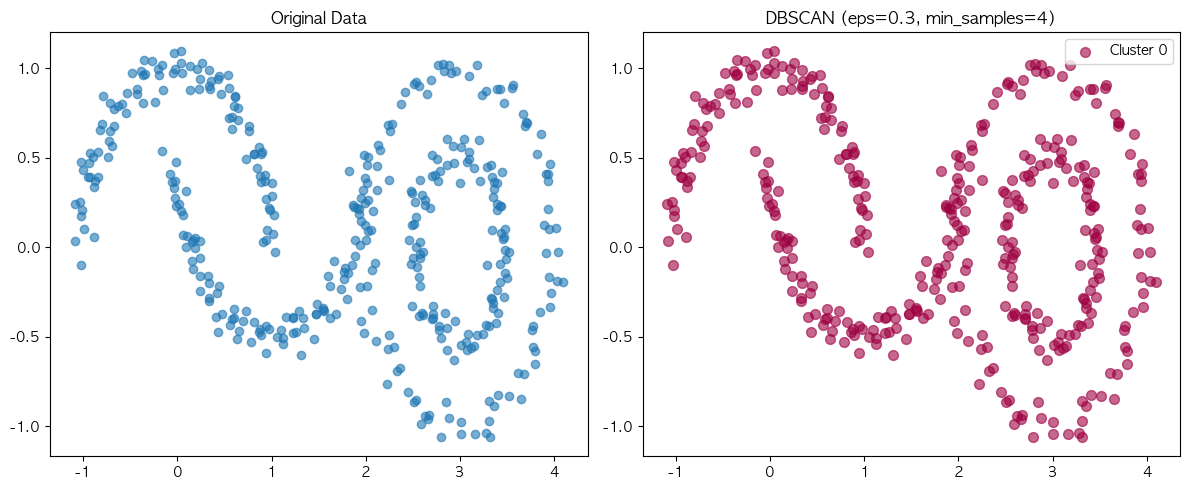

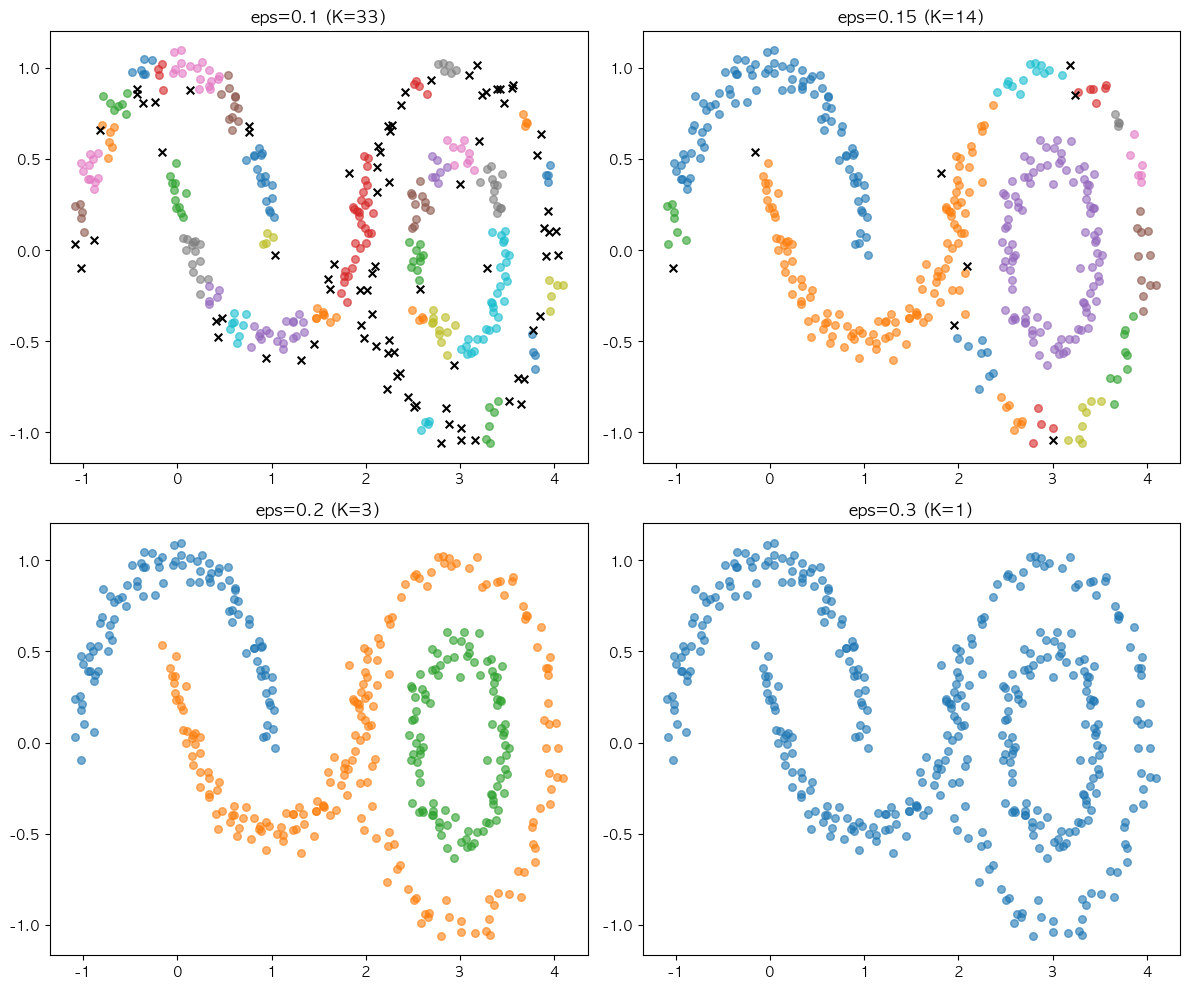

In [73]:
# DBSCAN 적용
dbscan = DBSCAN(eps=0.3, min_samples=4)
# min_samples=4 → 한 점 주변에 4개 이상 점이 모여 있으면 “밀도 높다”라고 본 거.
labels = dbscan.fit_predict(X)
# fit_predict(X) 하면 각 점이 몇 번 클러스터인지 번호를 돌려줌
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

# 시각화
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], alpha=0.6)
plt.title('Original Data')

# DBSCAN 결과
plt.subplot(1, 2, 2)
colors = plt.cm.Spectral(np.linspace(0, 1, n_clusters))
for k, col in zip(range(n_clusters), colors):
    class_member_mask = (labels == k)
    xy = X[class_member_mask]
    plt.scatter(xy[:, 0], xy[:, 1], c=[col], alpha=0.6,label=f'Cluster {k}', s=50)

# 노이즈
noise_mask = (labels == -1)
if np.any(noise_mask):
    plt.scatter(X[noise_mask, 0], X[noise_mask, 1],c='black', marker='x', s=50, label='Noise')
plt.title(f'DBSCAN (eps={0.3}, min_samples={4})')
plt.legend()
plt.tight_layout()
plt.show()
    
# 다양한 eps 비교

eps_values = [0.1,0.15, 0.2, 0.3]
fig, axes = plt.subplots(2, 2, figsize=(12, 10)) # 4개 eps 값(0.1.0.15, 0.2, 0.3)을 각각 돌려보고 2×2 서브플롯에 하나씩 그려줌
for idx, eps in enumerate(eps_values):
    dbscan = DBSCAN(eps=eps, min_samples=4)
    labels = dbscan.fit_predict(X)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    ax = axes[idx // 2, idx % 2]  # idx // 2, idx % 2 이건 “2×2 자리” 계산

    # 군집 그리기
    for k in range(n_clusters):
        mask = (labels == k)
        ax.scatter(X[mask, 0], X[mask, 1], alpha=0.6, s=30)

    # 노이즈
    noise_mask = (labels == -1)
    if np.any(noise_mask):
        ax.scatter(X[noise_mask, 0], X[noise_mask, 1],c='black', marker='x', s=30)
    ax.set_title(f'eps={eps} (K={n_clusters})')
    
plt.tight_layout()
plt.show()